# Run 2: true sky envelope, wavelet RJMCMC vs Riccardo's chunked (OG) posterior

**Stage 3, run 2.** Inject the signal Riccardo's pack-2 analysis was run on, the Galactic foreground modulated by the
true sky envelope $P_c(t)=M_c^2(t)$ (`lat, long, psi, s1, s2` of `pe_pack2_cyclo.yaml`, true amplitude
$\log_{10}A=-43.943$), and analyse it with the wavelet pipeline exactly as in
[run 1](run1_inject_recover.ipynb) (same priors, sampler settings and start at $K=0$). Then put the wavelet posterior
on $P_c(t)$ on top of the posterior-predictive envelope of the OG chunked run (`cyclo_riccardo/cyclo/result.hdf5`,
nessai, two 15-day chunks, 5 sky parameters) and ask: **which is broader?**

* Same data settings as the OG run: 30 d, $\Delta t=10$ s, 0.1–29 mHz, TDI gen 1.
* Same noise seed as run 1, so runs 1 and 2 differ only through the injected modulation (by < 1%).
* The OG posterior is **reused, not rerun**. Its data are a different noise realisation (the raw OG time series is not
  available, and the wavelet pipeline needs one), so compare band **widths**; band centres scatter independently.
* Both pipelines measure only amplitude × modulation, so the compared quantity is the galactic power relative to the
  true amplitude, $10^{\log_{10}A-\log_{10}A_{\rm true}}\,P_c(t)$, whose truth is $M_c^2(t)$.

Set `RERUN = True` to simulate and sample again (about 35 min on 8 cores).

In [1]:
import sys
from pathlib import Path
import numpy as np
import h5py
import matplotlib.pyplot as plt
import jax.numpy as jnp

ROOT = Path.cwd()
while not (ROOT / 'pyproject.toml').exists():
    ROOT = ROOT.parent
HERE = ROOT / 'data' / 'wavelet_injection'
sys.path.insert(0, str(HERE))
import injection as I
from bahamas.wavelet.model import DAY
from bahamas.wavelet.sampler import modulation_draws
from bahamas.wavelet.simulate import power_modulation, ENVELOPE_PARAMS

RERUN = False
OUT = HERE / 'outputs' / 'run2'
CMP = HERE / 'outputs' / 'comparison'
OUT.mkdir(parents=True, exist_ok=True)
CMP.mkdir(parents=True, exist_ok=True)
CH = ['A', 'E']
T_CHUNK = 1296000.0

C_TRUTH, C_WAV, C_WAV_L, C_OG, C_OG_L, C_MUTED = '#0b0b0b', '#2a78d6', '#86b6ef', '#eb6834', '#f5b48f', '#52514e'
plt.rcParams.update({'figure.dpi': 110, 'axes.grid': True, 'grid.alpha': 0.25, 'axes.spines.top': False,
                     'axes.spines.right': False, 'lines.linewidth': 1.5, 'legend.frameon': False})
cfg = I.CONFIG
amp_true, amp_ref = I.true_amp(), I.load_reference()['amp']
print(f'true amp {amp_true:.3f}; posterior reference amp (amp_eff of stage 2) {amp_ref:.3f}')
print('sky parameters:', I.sky_params())

2026-10-09 17:25:01,480 - BAHAMAS - INFO - Using JAX backend.


2026-10-09 17:25:01,483 - BAHAMAS - INFO - np is from: jax.numpy


true amp -43.943; posterior reference amp (amp_eff of stage 2) -43.267
sky parameters: {'lat': -0.09664565, 'long': -1.6259238, 'psi': -0.9900146151015816, 's1': 0.04156049812924856, 's2': 0.13842963137295858}


## 1. Data and injection

In [2]:
data, inj = I.load_or_simulate('sky', 'run2', rerun=RERUN)
like, post = I.build_posterior(data)
inj1 = I.injection_for('wavelet', data)
eb = cfg['wavelet']['edge_bins']
t_lo, t_hi = like.times[0], like.times[-1]          # centres of the first/last analysed time groups
print(f'analysed span (time-group centres): {t_lo / DAY:.2f} - {t_hi / DAY:.2f} d')

t_fine = np.linspace(0, inj.wm.T, 300)
for c in (0, 1):
    d = np.max(np.abs(inj.P_rel(t_fine, c) / inj1.P_rel(t_fine, c) - 1))
    print(f'{CH[c]}: max |run-2 injection / run-1 injection - 1| = {100 * d:.2f}%')

analysed span (time-group centres): 2.13 - 26.79 d


A: max |run-2 injection / run-1 injection - 1| = 0.78%


E: max |run-2 injection / run-1 injection - 1| = 0.90%


## 2. Sampling and convergence

The truth for the spectral parameters is known except for `amp` and `level_E`. With $b_A\equiv0$ the wavelet model
measures $\log_{10}A_{\rm eff}=\log_{10}A+b_A/\ln10$, and $b_A$ depends on how the atoms split the level, so the
stage-2 values ($-43.267$, $+0.443$) are shown as approximate references only.

runtime 29.5 min, 6000 steps x 32 walkers (cold chain); acceptance 0.078, RJ acceptance 0.007


A p(K=1)=0.289 p(K=2)=0.390 p(K=3)=0.213 p(K=4)=0.077 p(K=5)=0.018 p(K=6)=0.007 p(K=7)=0.005
E p(K=1)=0.556 p(K=2)=0.289 p(K=3)=0.110 p(K=4)=0.040 p(K=5)=0.005 p(K=6)=0.001


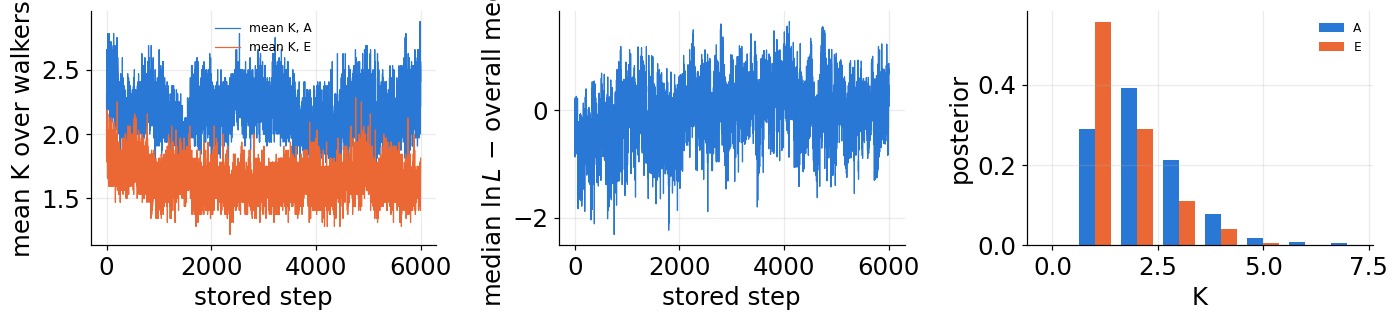

In [3]:
res_path = OUT / 'chains.npz'
if RERUN or not res_path.exists():
    I.run('sky', 'run2')
r = dict(np.load(res_path, allow_pickle=True))
nsteps, nw = int(r['nsteps']), int(r['nwalkers'])
print(f"runtime {float(r['runtime_s']) / 60:.1f} min, {nsteps} steps x {nw} walkers (cold chain); acceptance "
      f"{np.mean(r['acceptance_fraction']):.3f}, RJ acceptance {np.mean(r['rj_acceptance_fraction']):.3f}")

fig, axes = plt.subplots(1, 3, figsize=(13, 3.2))
for c, col in zip(CH, [C_WAV, C_OG]):
    axes[0].plot(r[f'mod_{c}_nleaves'].reshape(nsteps, nw).mean(1), color=col, lw=0.8, label=f'mean K, {c}')
axes[0].set_xlabel('stored step'); axes[0].set_ylabel('mean K over walkers'); axes[0].legend(fontsize=8)
ll = r['log_like'].reshape(nsteps, nw)
axes[1].plot(np.median(ll, 1) - np.median(ll), color=C_WAV, lw=0.8)
axes[1].set_xlabel('stored step'); axes[1].set_ylabel(r'median $\ln L$ − overall median')
w = 0.38
for i, (c, col) in enumerate(zip(CH, [C_WAV, C_OG])):
    K, p = r[f'mod_{c}_bayes_K'], r[f'mod_{c}_bayes_posterior']
    axes[2].bar(K + (i - 0.5) * w, p, width=w, color=col, label=c)
    print(c, ' '.join(f'p(K={k})={q:.3f}' for k, q in zip(K, p) if q > 1e-3))
axes[2].set_xlabel('K'); axes[2].set_ylabel('posterior'); axes[2].set_xlim(-0.6, 7.6); axes[2].legend(fontsize=8)
fig.tight_layout()
fig.savefig(OUT / 'convergence_K.png', dpi=150)

## 3. Riccardo's OG posterior

Posterior-predictive galactic power from the nessai samples:
$10^{\log_{10}A-\log_{10}A_{\rm true}}\,M_c^2(t;\,{\rm lat, long, psi, s1, s2})$, 1000 random draws.

In [4]:
with h5py.File(I.OG_RESULT, 'r') as f:
    og = f['posterior_samples'][()]
rng = np.random.default_rng(0)
og_draws = og[rng.choice(len(og), 1000, replace=False)]
truth_src = {p['name']: p['injected'] for s in I.og_sources().values() for p in s}

def og_power(d, t):
    sky = {k: float(d[k]) for k in ENVELOPE_PARAMS}
    return 10 ** (float(d['amp']) - amp_true) * np.stack([np.asarray(power_modulation(sky, t, c)) for c in (0, 1)])

P_og = np.array([og_power(d, t_fine) for d in og_draws])                        # (ndraw, 2, nt)
P_wav = 10 ** (amp_ref - amp_true) * modulation_draws(post, r, t_fine, nsamples=1000, seed=0)
P_true = np.stack([np.asarray(power_modulation(I.sky_params(), t_fine, c)) for c in (0, 1)])
print(f'{len(og)} OG samples; draws: OG {P_og.shape}, wavelet {P_wav.shape}')

11537 OG samples; draws: OG (1000, 2, 300), wavelet (1000, 2, 300)


## 4. Spectral parameters: OG vs wavelet

The parameters the two models share (`amp` is compared through the galactic power in §5, since the wavelet $b_A\equiv0$
convention shifts it).

param     truth | OG median 90% width | wav median 90% width | width wav/OG
alpha     1.800 |     1.927    0.1864 |      1.824    0.2185 | 1.17
fknee    -2.177 |    -2.176    0.0091 |     -2.175    0.0080 | 0.88
fr1      -2.429 |    -2.416    0.0233 |     -2.422    0.0285 | 1.22
fr2      -3.488 |    -3.513    0.3138 |     -3.500    0.2333 | 0.74
A         2.400 |     2.397    0.1457 |      2.435    0.1269 | 0.87
P         7.900 |     7.882    0.0618 |      7.900    0.0446 | 0.72


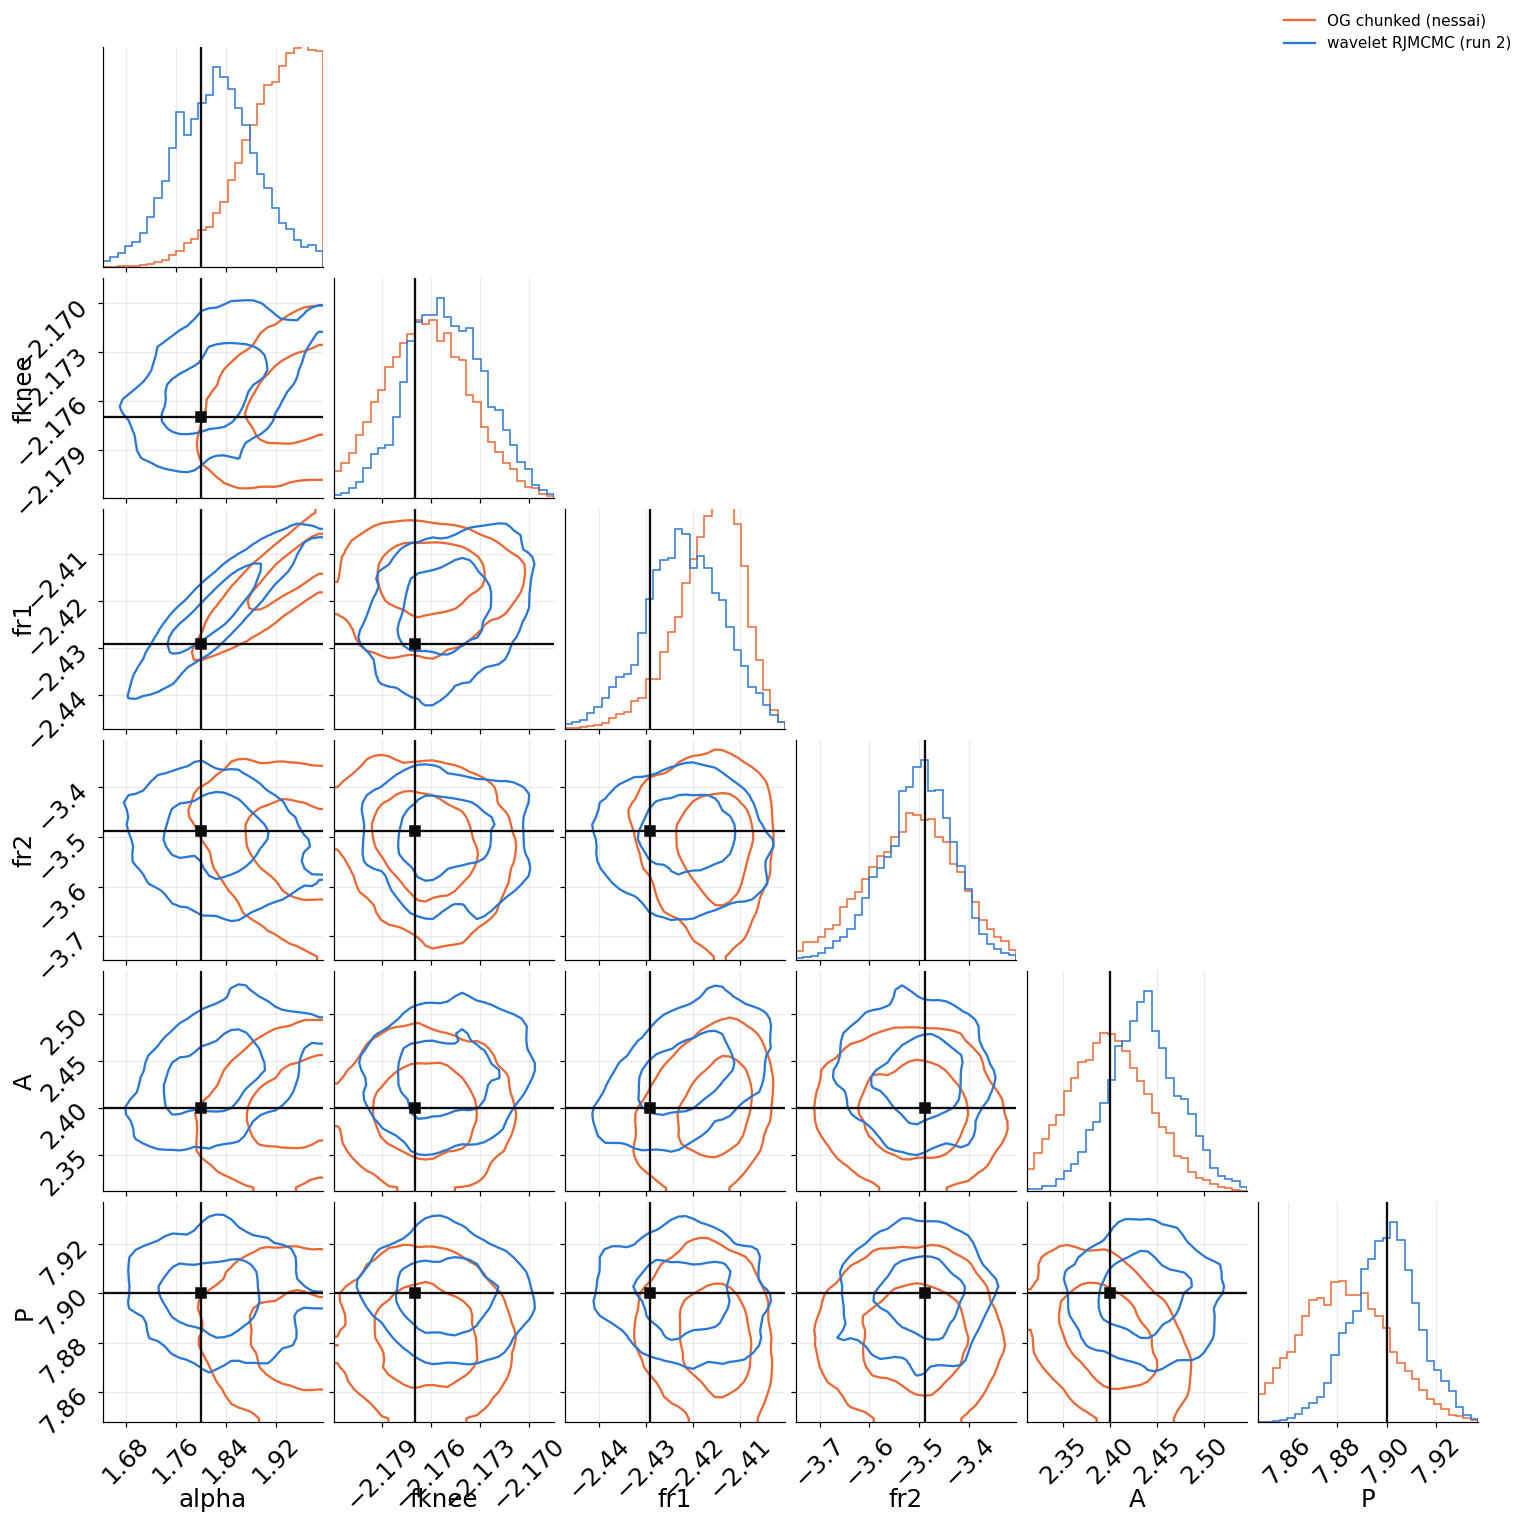

In [5]:
import corner
shared = ['alpha', 'fknee', 'fr1', 'fr2', 'A', 'P']
names = [str(n).split(':')[-1] for n in r['psd_names']]
wav = np.column_stack([r['psd_chain'][:, names.index(k)] for k in shared])
ogs = np.column_stack([og[k] for k in shared])
truths = [truth_src[k] for k in shared]
rng_ = [tuple(np.percentile(np.r_[wav[:, i], ogs[:, i]], [0.2, 99.8])) for i in range(len(shared))]
fig = corner.corner(ogs, labels=shared, color=C_OG, range=rng_, bins=30, smooth=1.0, plot_datapoints=False,
                    plot_density=False, levels=(0.5, 0.9), hist_kwargs={'density': True})
corner.corner(wav, fig=fig, color=C_WAV, range=rng_, bins=30, smooth=1.0, plot_datapoints=False, plot_density=False,
              levels=(0.5, 0.9), truths=truths, truth_color=C_TRUTH, hist_kwargs={'density': True})
fig.legend(handles=[plt.Line2D([], [], color=C_OG, label='OG chunked (nessai)'),
                    plt.Line2D([], [], color=C_WAV, label='wavelet RJMCMC (run 2)')], loc='upper right', fontsize=10)
fig.savefig(CMP / 'corner_spectral_og_vs_wavelet.png', dpi=110)

print(f"{'param':6s} {'truth':>8s} | {'OG median':>9s} {'90% width':>9s} | {'wav median':>10s} {'90% width':>9s} | width wav/OG")
for i, k in enumerate(shared):
    qo, qw = np.percentile(ogs[:, i], [5, 50, 95]), np.percentile(wav[:, i], [5, 50, 95])
    print(f'{k:6s} {truths[i]:8.3f} | {qo[1]:9.3f} {qo[2] - qo[0]:9.4f} | {qw[1]:10.3f} {qw[2] - qw[0]:9.4f} | {(qw[2] - qw[0]) / (qo[2] - qo[0]):.2f}')

## 5. The modulation: OG and wavelet posteriors on top of each other

90% (light) and 50% (dark) bands of the galactic power relative to the true amplitude. Dashed: the injected
$M_c^2(t)$. Dotted vertical line: the boundary of the two 15-day OG chunks. Grey: the time bins the wavelet likelihood
drops at each end; the wavelet band there is extrapolation. Lower panels: 90% width relative to the truth.

A: median 90% width / P  OG 10.9%  wavelet 11.5%  -> wavelet/OG = 1.06   | truth inside 90%: OG 0%, wavelet 100% of the analysed span
E: median 90% width / P  OG 10.3%  wavelet 10.5%  -> wavelet/OG = 1.01   | truth inside 90%: OG 0%, wavelet 98% of the analysed span


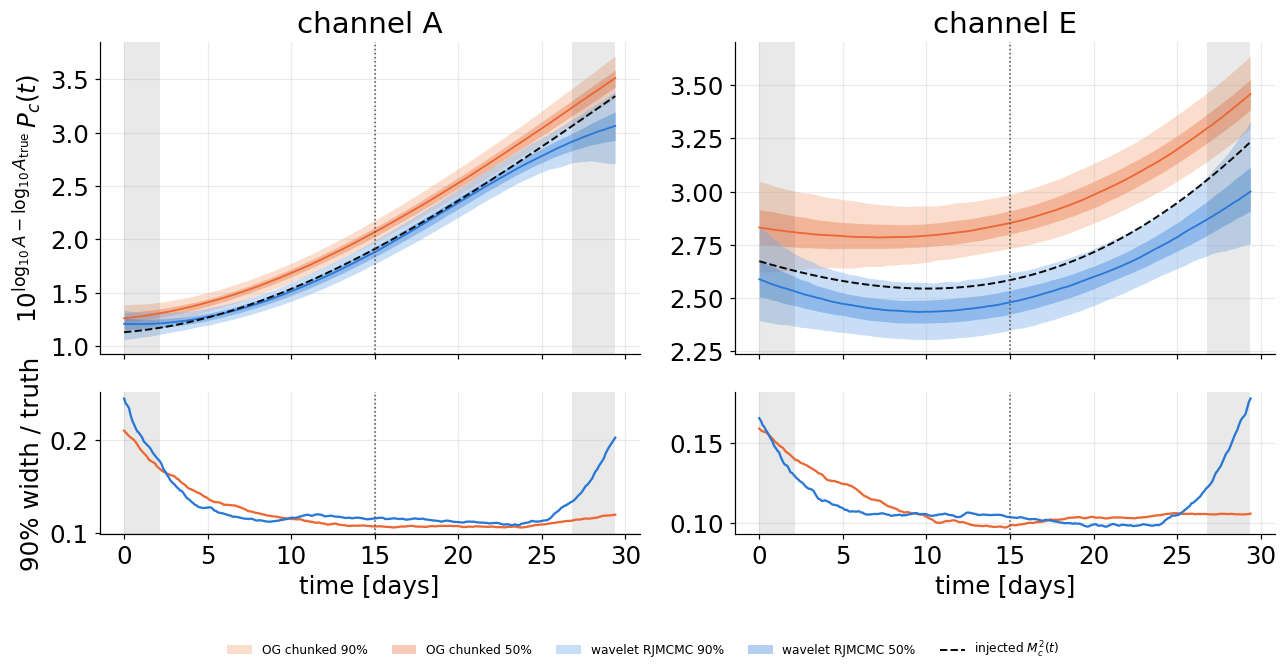

In [6]:
q_og, q_wav = (np.percentile(P, [5, 25, 50, 75, 95], axis=0) for P in (P_og, P_wav))
td = t_fine / DAY
inside = (t_fine >= t_lo) & (t_fine <= t_hi)
summary = {}

fig, axes = plt.subplots(2, 2, figsize=(12, 6.2), sharex=True, gridspec_kw={'height_ratios': [2.2, 1]})
for i, c in enumerate(CH):
    ax, axw = axes[0, i], axes[1, i]
    for q, cl, cd, lab in [(q_og, C_OG_L, C_OG, 'OG chunked'), (q_wav, C_WAV_L, C_WAV, 'wavelet RJMCMC')]:
        ax.fill_between(td, q[0, i], q[4, i], color=cl, alpha=0.45, lw=0, label=f'{lab} 90%')
        ax.fill_between(td, q[1, i], q[3, i], color=cd, alpha=0.35, lw=0, label=f'{lab} 50%')
        ax.plot(td, q[2, i], color=cd, lw=1.2)
        axw.plot(td, (q[4, i] - q[0, i]) / P_true[i], color=cd, label=lab)
    ax.plot(td, P_true[i], color=C_TRUTH, ls='--', lw=1.3, label=r'injected $M_c^2(t)$')
    for a in (ax, axw):
        a.axvline(T_CHUNK / DAY, color=C_MUTED, ls=':', lw=1)
        a.axvspan(0, t_lo / DAY, color=C_MUTED, alpha=0.12, lw=0)
        a.axvspan(t_hi / DAY, td[-1], color=C_MUTED, alpha=0.12, lw=0)
    ax.set_title(f'channel {c}')
    axw.set_xlabel('time [days]')
    w_og = np.median((q_og[4, i] - q_og[0, i])[inside] / P_true[i, inside])
    w_wav = np.median((q_wav[4, i] - q_wav[0, i])[inside] / P_true[i, inside])
    cov = lambda q: np.mean(((q[0, i] <= P_true[i]) & (P_true[i] <= q[4, i]))[inside])
    summary[c] = (w_og, w_wav)
    print(f'{c}: median 90% width / P  OG {100 * w_og:.1f}%  wavelet {100 * w_wav:.1f}%  -> wavelet/OG = {w_wav / w_og:.2f}'
          f'   | truth inside 90%: OG {100 * cov(q_og):.0f}%, wavelet {100 * cov(q_wav):.0f}% of the analysed span')
axes[0, 0].set_ylabel(r'$10^{\log_{10}A-\log_{10}A_{\rm true}}\,P_c(t)$')
axes[1, 0].set_ylabel('90% width / truth')
h, l = axes[0, 0].get_legend_handles_labels()
fig.tight_layout(rect=(0, 0.06, 1, 1))
fig.legend(h, l, loc='lower center', ncol=5, fontsize=8)
fig.savefig(CMP / 'modulation_og_vs_wavelet.png', dpi=150, bbox_inches='tight')

### Why the OG band misses the truth

The OG band sits 6–10% above the injection over the whole window, in both channels, while its *shape* agrees (next
plot). The data of a chunked run constrain the chunk averages $10^{\Delta\log_{10}A}\,\bar M_c$, so check those directly,
together with two candidate explanations: (i) the stage-1 note that the yaml injects $\sin\psi=-0.990$ while paper 2
quotes $-0.83$; (ii) the OG `alpha` posterior piling against its prior bound of 2.

In [7]:
first = t_fine < T_CHUNK
chunk_means = lambda P: np.stack([P[..., first].mean(-1), P[..., ~first].mean(-1)], -1)   # (..., channel, chunk)
ratio = chunk_means(P_og) / chunk_means(P_true)
q = np.percentile(ratio, [5, 50, 95], axis=0)
alt = np.stack([np.asarray(power_modulation({**I.sky_params(), 'psi': -0.83}, t_fine, c)) for c in (0, 1)])
r_alt = chunk_means(alt) / chunk_means(P_true)
print('OG posterior 10^dA * chunk mean / truth    [5%, median, 95%]      | sin(psi) = -0.83 instead of -0.99')
for i, c in enumerate(CH):
    for j in range(2):
        print(f'  {c} chunk {j + 1}:  [{q[0, i, j]:.3f}, {q[1, i, j]:.3f}, {q[2, i, j]:.3f}]                   | {r_alt[i, j]:.3f}')
print(f"\nOG alpha: median {np.median(og['alpha']):.3f}, 95% {np.percentile(og['alpha'], 95):.3f}, prior bound 2.0; "
      f"fraction of samples above 1.95: {np.mean(og['alpha'] > 1.95):.2f}")
print(f"OG sin(psi): median {np.median(og['psi']):+.3f}, 90% [{np.percentile(og['psi'], 5):+.3f}, {np.percentile(og['psi'], 95):+.3f}] (yaml truth -0.990)")

OG posterior 10^dA * chunk mean / truth    [5%, median, 95%]      | sin(psi) = -0.83 instead of -0.99
  A chunk 1:  [1.046, 1.102, 1.164]                   | 1.176
  A chunk 2:  [1.015, 1.064, 1.119]                   | 1.100
  E chunk 1:  [1.034, 1.087, 1.146]                   | 1.095
  E chunk 2:  [1.042, 1.090, 1.144]                   | 1.070

OG alpha: median 1.927, 95% 1.992, prior bound 2.0; fraction of samples above 1.95: 0.35
OG sin(psi): median -0.842, 90% [-0.975, -0.554] (yaml truth -0.990)


### Shape only

The amplitude is common to all times, so part of each band above is just the amplitude uncertainty. Dividing every
draw by its own mean over the analysed span removes it and leaves the constraint on the **time dependence** alone.

A shape: median 90% width  OG 3.8%  wavelet 5.1%  -> wavelet/OG = 1.35
E shape: median 90% width  OG 3.9%  wavelet 3.6%  -> wavelet/OG = 0.94


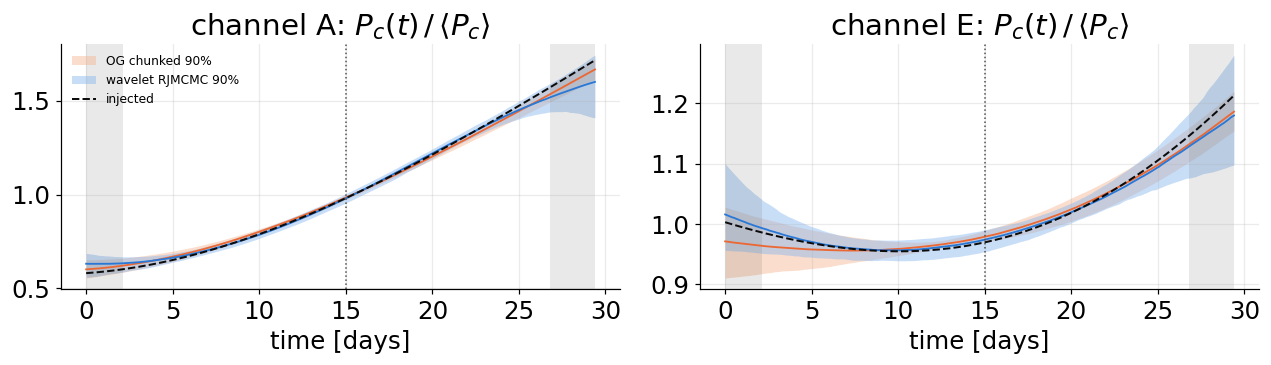

In [8]:
def shape(P):
    return P / P[..., inside].mean(axis=-1, keepdims=True)

S_og, S_wav, S_true = shape(P_og), shape(P_wav), shape(P_true)
s_og, s_wav = (np.percentile(S, [5, 25, 50, 75, 95], axis=0) for S in (S_og, S_wav))
fig, axes = plt.subplots(1, 2, figsize=(12, 3.6), sharex=True)
for i, (ax, c) in enumerate(zip(axes, CH)):
    for q, cl, cd, lab in [(s_og, C_OG_L, C_OG, 'OG chunked'), (s_wav, C_WAV_L, C_WAV, 'wavelet RJMCMC')]:
        ax.fill_between(td, q[0, i], q[4, i], color=cl, alpha=0.45, lw=0, label=f'{lab} 90%')
        ax.plot(td, q[2, i], color=cd, lw=1.2)
    ax.plot(td, S_true[i], color=C_TRUTH, ls='--', lw=1.3, label='injected')
    ax.axvline(T_CHUNK / DAY, color=C_MUTED, ls=':', lw=1)
    ax.axvspan(0, t_lo / DAY, color=C_MUTED, alpha=0.12, lw=0)
    ax.axvspan(t_hi / DAY, td[-1], color=C_MUTED, alpha=0.12, lw=0)
    ax.set_title(f'channel {c}: $P_c(t)\\,/\\,\\langle P_c\\rangle$')
    ax.set_xlabel('time [days]')
    w_og = np.median((s_og[4, i] - s_og[0, i])[inside])
    w_wav = np.median((s_wav[4, i] - s_wav[0, i])[inside])
    print(f'{c} shape: median 90% width  OG {100 * w_og:.1f}%  wavelet {100 * w_wav:.1f}%  -> wavelet/OG = {w_wav / w_og:.2f}')
axes[0].legend(fontsize=8)
fig.tight_layout()
fig.savefig(CMP / 'shape_og_vs_wavelet.png', dpi=150)

## 6. Summary

The numbers above are collected in [reports/WAVELET_INJECTION_RUN2.md](../../reports/WAVELET_INJECTION_RUN2.md).